# Graphical circuit visualization

This notebook demonstrates the matplotlib-based circuit renderer exposed through `Circuit.show()`. Alongside the existing Unicode text diagram (`print(circuit)`), you can now render any `Circuit` as a matplotlib `Figure`.

Highlights:
- Gates render as labelled rounded boxes
- Controls render as filled dots, anti-controls as open dots
- Multi-qubit gates draw a vertical connection line between their qubits
- SWAP renders as an `x` on each qubit, joined by a vertical line
- Barriers render as dashed vertical lines
- Global phase, additional result types, and unassigned parameters appear in a footer

Requires `matplotlib` (installed as part of the SDK).

In [1]:
import matplotlib.pyplot as plt
from braket.circuits import Circuit, FreeParameter, Observable
from braket.circuits.graphical_diagram_builders import MatplotlibCircuitDiagram

## 1. Bell state

The canonical two-qubit entangling circuit. `show()` returns a matplotlib `Figure` by default, so Jupyter will display it inline.

T  : │  0  │  1  │
      ┌───┐       
q0 : ─┤ H ├───●───
      └───┘   │   
            ┌─┴─┐ 
q1 : ───────┤ X ├─
            └───┘ 
T  : │  0  │  1  │


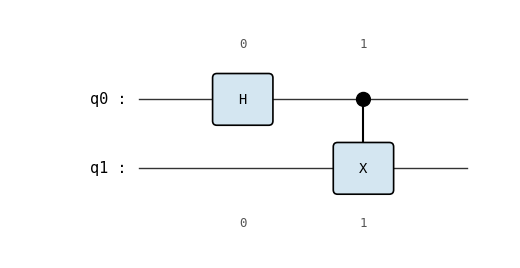

In [2]:
bell = Circuit().h(0).cnot(0, 1)
print(bell)
bell.show()

## 2. Controls and anti-controls

A controlled-Z with a positive control on qubit 0 and an anti-control on qubit 2 (open dot). Any gate can be wrapped with `.control` and `.control_state`.

T  : │  0  │
            
q0 : ───●───
        │   
      ┌─┴─┐ 
q1 : ─┤ X ├─
      └─┬─┘ 
        │   
q2 : ───◯───
            
T  : │  0  │


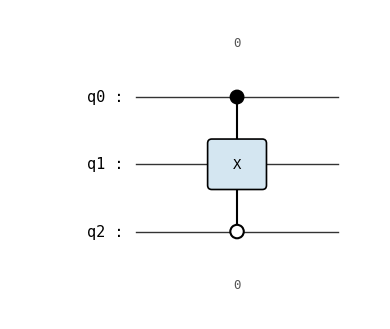

In [3]:
controlled = Circuit().x(1, control=[0, 2], control_state=[1, 0])
print(controlled)
controlled.show()

## 3. Parallel gates in the same moment

Independent gates that act on disjoint qubit ranges appear in the same column without their connection lines bridging.

T  : │  0  │
            
q0 : ───●───
        │   
      ┌─┴─┐ 
q1 : ─┤ X ├─
      └───┘ 
            
q2 : ───●───
        │   
      ┌─┴─┐ 
q3 : ─┤ X ├─
      └───┘ 
      ┌───┐ 
q4 : ─┤ H ├─
      └───┘ 
T  : │  0  │


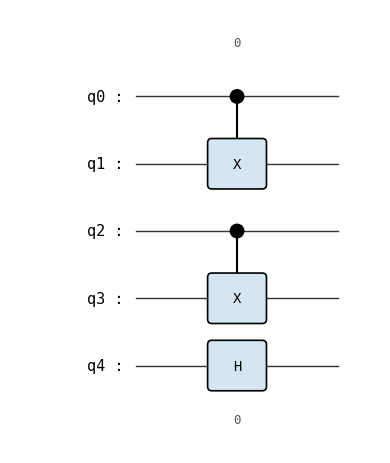

In [4]:
parallel = Circuit().cnot(0, 1).cnot(2, 3).h(4)
print(parallel)
parallel.show()

## 4. GHZ state with a SWAP

A three-qubit GHZ state followed by a SWAP to show the `x` markers joined by a connection line.

T  : │  0  │  1  │  2  │   3    │
      ┌───┐                      
q0 : ─┤ H ├───●────────────x─────
      └───┘   │            │     
            ┌─┴─┐          │     
q1 : ───────┤ X ├───●──────┼─────
            └───┘   │      │     
                  ┌─┴─┐    │     
q2 : ─────────────┤ X ├────x─────
                  └───┘          
T  : │  0  │  1  │  2  │   3    │


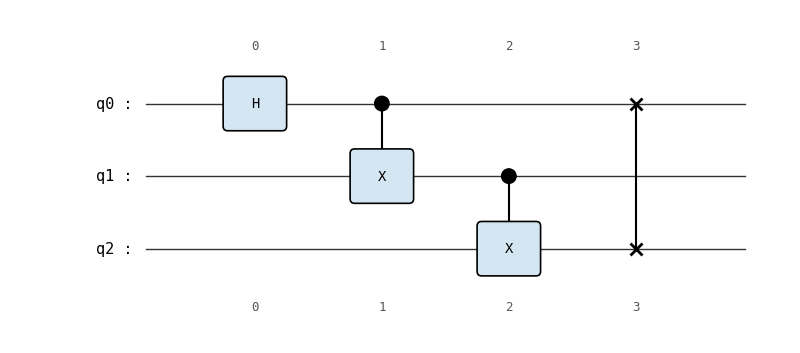

In [5]:
ghz = Circuit().h(0).cnot(0, 1).cnot(1, 2).swap(0, 2)
print(ghz)
ghz.show()

## 5. Barriers

Barriers render as dashed vertical lines spanning the qubits they target. A barrier with no explicit target spans all qubits in the circuit.

T  : │  0  │  1   │  2  │  3  │
      ┌───┐                    
q0 : ─┤ H ├───▒──────●─────────
      └───┘          │         
      ┌───┐        ┌─┴─┐       
q1 : ─┤ H ├────────┤ X ├───●───
      └───┘        └───┘   │   
      ┌───┐              ┌─┴─┐ 
q2 : ─┤ H ├───▒──────────┤ X ├─
      └───┘              └───┘ 
T  : │  0  │  1   │  2  │  3  │


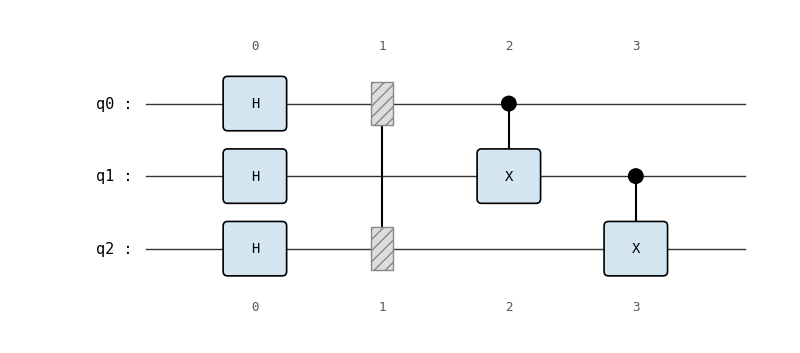

In [6]:
barriered = Circuit().h(0).h(1).h(2).barrier([0, 2]).cnot(0, 1).cnot(1, 2)
print(barriered)
barriered.show()

### Barrier spanning every qubit

Calling `.barrier()` without a target argument adds a barrier that applies to every qubit in the circuit. The dashed vertical line spans the full height of the diagram.

T  : │  0  │  1   │  2  │  3  │
      ┌───┐                    
q0 : ─┤ H ├───▒──────●─────────
      └───┘   │      │         
      ┌───┐   │    ┌─┴─┐       
q1 : ─┤ H ├───▒────┤ X ├───●───
      └───┘   │    └───┘   │   
      ┌───┐   │          ┌─┴─┐ 
q2 : ─┤ H ├───▒──────────┤ X ├─
      └───┘              └───┘ 
T  : │  0  │  1   │  2  │  3  │


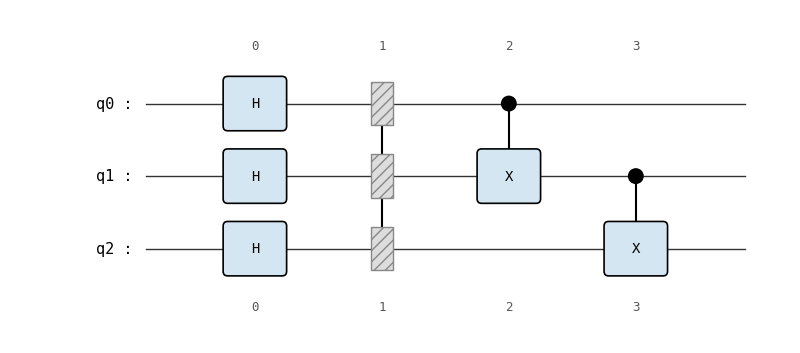

In [7]:
# A barrier with no explicit target spans every qubit in the circuit.
barrier_all = Circuit().h(0).h(1).h(2).barrier().cnot(0, 1).cnot(1, 2)
print(barrier_all)
barrier_all.show()

## 6. Verbatim boxes

A verbatim box marks a subcircuit that the compiler must execute exactly as written, without optimization or rewriting. In the diagram, `StartVerbatim` and `EndVerbatim` render as labelled columns that bracket the protected region, connected by a vertical line across every qubit.

T  : │  0  │        1        │  2  │  3  │     4      │       5       │  6  │
      ┌───┐                   ┌───┐                                    ┌───┐ 
q0 : ─┤ X ├───StartVerbatim───┤ H ├───●──────────────────EndVerbatim───┤ H ├─
      └───┘         ║         └───┘   │                       ║        └───┘ 
                    ║               ┌─┴─┐ ┌──────────┐        ║              
q1 : ───────────────╨───────────────┤ X ├─┤ Rz(0.50) ├────────╨──────────────
                                    └───┘ └──────────┘                       
T  : │  0  │        1        │  2  │  3  │     4      │       5       │  6  │


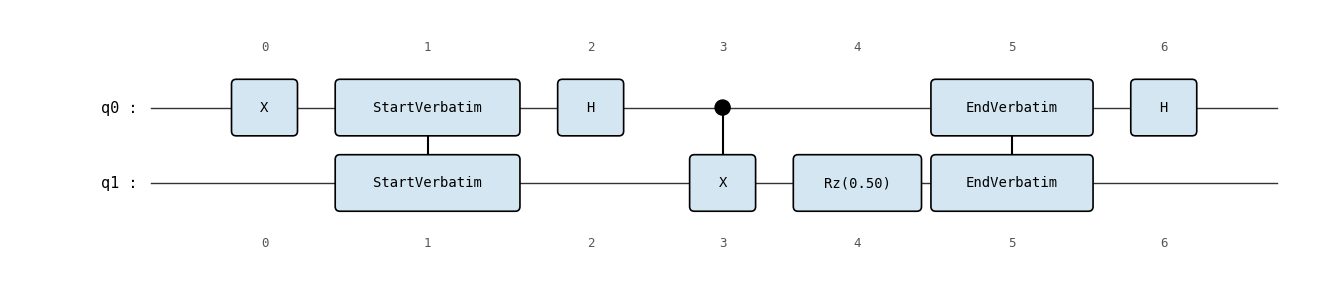

In [8]:
inner = Circuit().h(0).cnot(0, 1).rz(1, 0.5)
verbatim = Circuit().x(0).add_verbatim_box(inner).h(0)
print(verbatim)
verbatim.show()

## 7. Result types, global phase, and unassigned parameters

Targeted result types get their own columns on the right. Additional (circuit-wide) result types, global phase, and unassigned free parameters appear in the footer below the wires.

T  : │      0      │  1  │           Result Types           │
GP : │    0.50     │0.50 │       0.50       │     0.50      │
      ┌───────────┐       ┌────────────────┐ ┌─────────────┐ 
q0 : ─┤ Rx(theta) ├───●───┤ Expectation(Z) ├─┤ Probability ├─
      └───────────┘   │   └────────────────┘ └──────┬──────┘ 
       ┌─────────┐  ┌─┴─┐                    ┌──────┴──────┐ 
q1 : ──┤ Ry(phi) ├──┤ X ├────────────────────┤ Probability ├─
       └─────────┘  └───┘                    └─────────────┘ 
T  : │      0      │  1  │           Result Types           │

Global phase: 0.5

Unassigned parameters: [phi, theta].


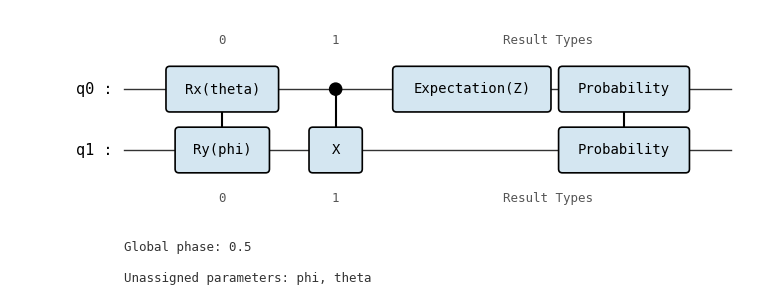

In [9]:
theta = FreeParameter("theta")
phi = FreeParameter("phi")

annotated = (
    Circuit()
    .gphase(0.5)
    .rx(0, theta)
    .ry(1, phi)
    .cnot(0, 1)
    .expectation(Observable.Z(), target=0)
    .probability()
)
print(annotated)
annotated.show()

## 8. Saving the figure

`MatplotlibCircuitDiagram.build_diagram(circuit)` returns the `Figure` directly, which is handy for saving to disk or embedding in reports.

In [10]:
fig = MatplotlibCircuitDiagram.build_diagram(ghz)
fig.savefig("ghz_circuit_graphic_diagram.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved ghz_circuit.png")

Saved ghz_circuit.png


## 9. Customizing the renderer

`Circuit.show(circuit_diagram_class=...)` accepts any class that implements `build_diagram(circuit)`. You can subclass `MatplotlibCircuitDiagram` and override the class-level style constants to change colors, sizes, and fonts without rewriting the layout logic.

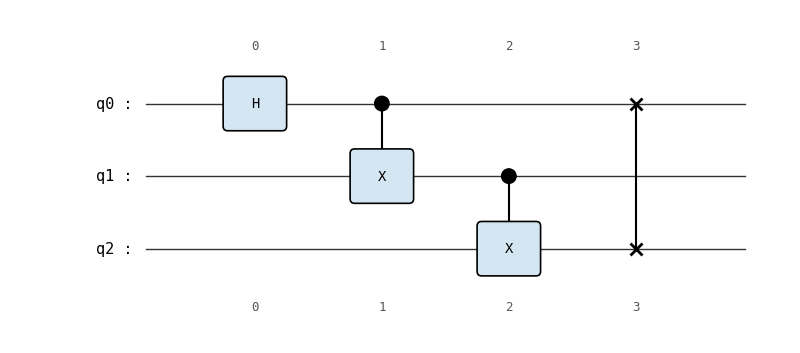

In [11]:
class DarkCircuitDiagram(MatplotlibCircuitDiagram):
    GATE_FILL_COLOR = "#1F2A44"
    GATE_EDGE_COLOR = "#8AB4F8"
    GATE_TEXT_COLOR = "#F8F9FA"
    WIRE_COLOR = "#AAAAAA"
    CONNECTION_COLOR = "#8AB4F8"
    CONTROL_DOT_COLOR = "#8AB4F8"


ghz.show(circuit_diagram_class=DarkCircuitDiagram)

In [12]:
print(ghz)

T  : │  0  │  1  │  2  │   3    │
      ┌───┐                      
q0 : ─┤ H ├───●────────────x─────
      └───┘   │            │     
            ┌─┴─┐          │     
q1 : ───────┤ X ├───●──────┼─────
            └───┘   │      │     
                  ┌─┴─┐    │     
q2 : ─────────────┤ X ├────x─────
                  └───┘          
T  : │  0  │  1  │  2  │   3    │


## 10. A longer circuit: 5-qubit QFT

A larger example showing how the renderer scales across many moments. This is a standard Quantum Fourier Transform on 5 qubits: Hadamards interleaved with controlled phase rotations, followed by bit-reversal swaps.

T  : │  0  │       1       │          2          │  ╏
      ┌───┐ ┌─────────────┐ ┌─────────────┐         ╏
q0 : ─┤ H ├─┤ PHASE(1.57) ├─┤ PHASE(0.79) ├───────  ╏
      └───┘ └──────┬──────┘ └──────┬──────┘         ╏
                   │               │        ┌───┐   ╏
q1 : ──────────────●───────────────┼────────┤ H ├─  ╏
                                   │        └───┘   ╏
                                   │                ╏
q2 : ──────────────────────────────●──────────────  ╏
                                                    ╏
                                                    ╏
q3 : ─────────────────────────────────────────────  ╏
                                                    ╏
                                                    ╏
q4 : ─────────────────────────────────────────────  ╏
                                                    ╏
T  : │  0  │       1       │          2          │  ╏
                                                    ╏                          
╸╸

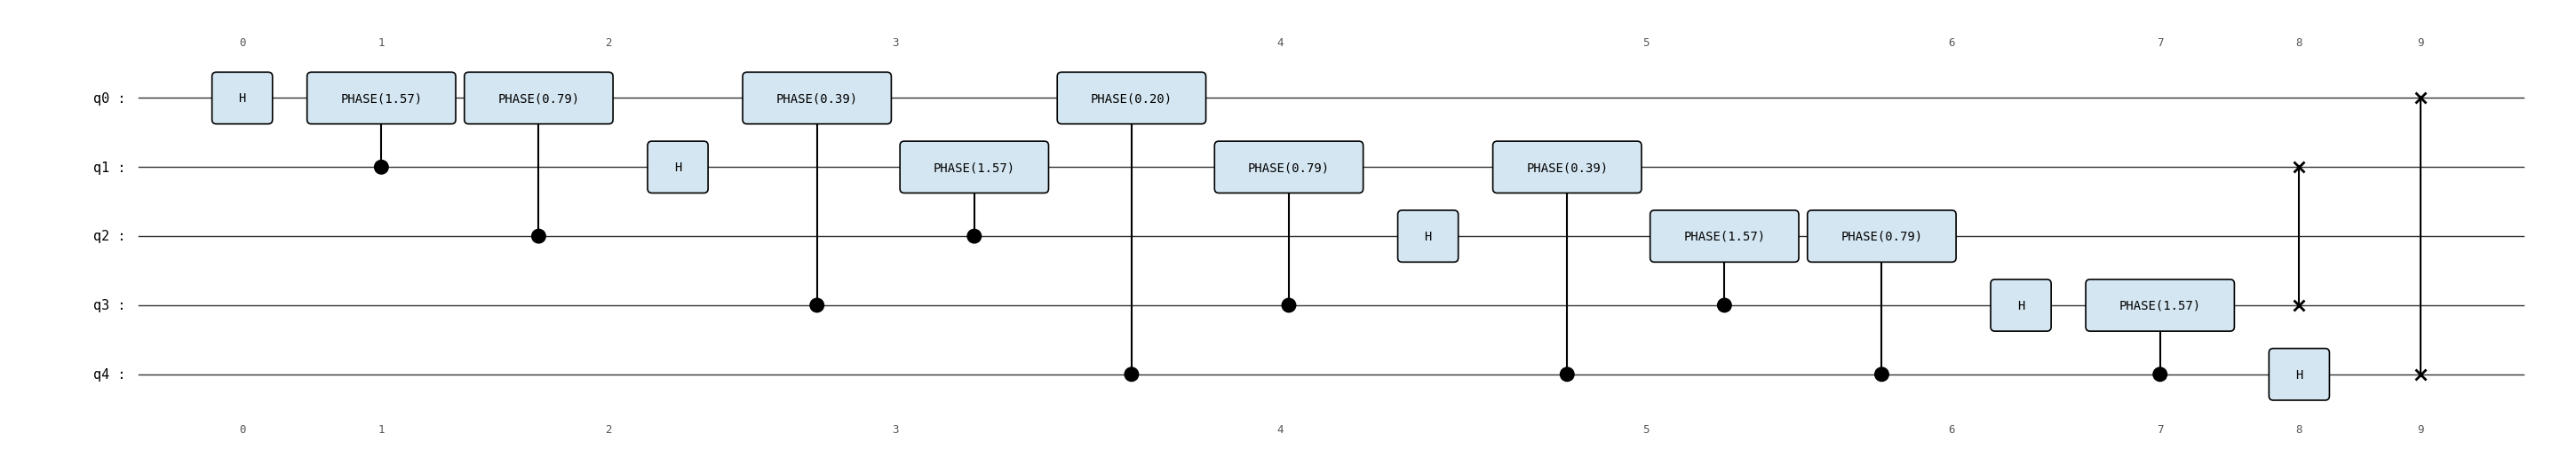

In [13]:
import math


def qft(num_qubits: int) -> Circuit:
    circuit = Circuit()
    for target in range(num_qubits):
        circuit.h(target)
        for control in range(target + 1, num_qubits):
            angle = math.pi / (2 ** (control - target))
            circuit.cphaseshift(control, target, angle)
    for i in range(num_qubits // 2):
        circuit.swap(i, num_qubits - 1 - i)
    return circuit


qft5 = qft(5)
print(qft5)
qft5.show()

## 11. A longer variational circuit: 4-qubit, 3-layer hardware-efficient ansatz

A parameterized circuit with repeated layers of single-qubit rotations and entangling CNOTs, typical of VQE/QAOA workloads. Barriers between layers make the repeating structure easy to see, and the footer lists every unassigned free parameter.

Parameters: 24


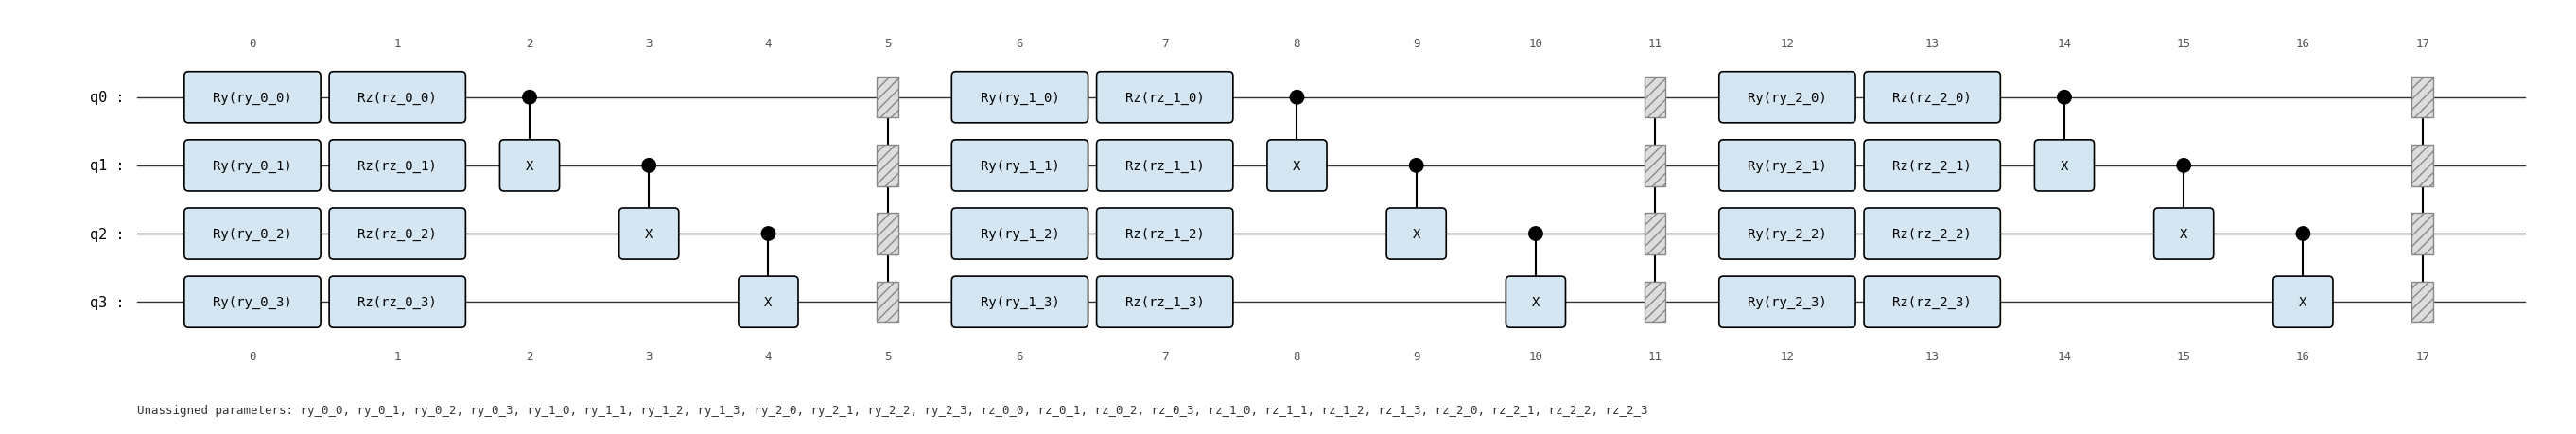

In [14]:
def hardware_efficient_ansatz(num_qubits: int, num_layers: int) -> Circuit:
    circuit = Circuit()
    for layer in range(num_layers):
        for q in range(num_qubits):
            circuit.ry(q, FreeParameter(f"ry_{layer}_{q}"))
            circuit.rz(q, FreeParameter(f"rz_{layer}_{q}"))
        for q in range(num_qubits - 1):
            circuit.cnot(q, q + 1)
        circuit.barrier()
    return circuit


ansatz = hardware_efficient_ansatz(num_qubits=4, num_layers=3)
print(f"Parameters: {len(ansatz.parameters)}")
ansatz.show()

## Text diagram remains available

The graphical renderer is additive. The Unicode text diagram you get from `print(circuit)` or `str(circuit)` is unchanged, which is useful in terminals, logs, and CI output.

In [15]:
print(annotated)

T  : │      0      │  1  │           Result Types           │
GP : │    0.50     │0.50 │       0.50       │     0.50      │
      ┌───────────┐       ┌────────────────┐ ┌─────────────┐ 
q0 : ─┤ Rx(theta) ├───●───┤ Expectation(Z) ├─┤ Probability ├─
      └───────────┘   │   └────────────────┘ └──────┬──────┘ 
       ┌─────────┐  ┌─┴─┐                    ┌──────┴──────┐ 
q1 : ──┤ Ry(phi) ├──┤ X ├────────────────────┤ Probability ├─
       └─────────┘  └───┘                    └─────────────┘ 
T  : │      0      │  1  │           Result Types           │

Global phase: 0.5

Unassigned parameters: [phi, theta].
